In [1]:
import pandas as pd
from matplotlib import pyplot as plt

from pathlib import Path

from xaikd import constants

from glob import glob

In [2]:
ARTIFACT_DIR = Path("../../artifacts/2025-02-s49/experiments/perf-curve/run-3")

In [3]:
def load_data(model, layer, dataset_name, basis_name, verbose=False, ref_col="ref_auroc", stat_col="val_auroc"):
    path = ARTIFACT_DIR / model / dataset_name / layer / basis_name / "stats.csv"
    if verbose:
        print(f"path: {path}")
    files = sorted(list(glob(f"{path}")))
    
    arr_dfs = [pd.read_csv(f) for f in files]
    
    df = pd.concat(arr_dfs)

    assert (df.arch.values == model).all()
    assert len(df.basis_name.unique()) == 1
    assert len(df.layer.unique()) == 1

    # return df
    
    df = df.groupby(["k"]).agg({
        ref_col: ["mean", "sem", "count"],
        stat_col: ["mean", "sem", "count"],
        "d": ["mean"]
    }).reset_index()
    
    return df
    
load_data("cifar100-resnet18-v1", "layer1", "cifar100-*-vs-others", "pca", verbose=True)

path: ../../artifacts/2025-02-s49/experiments/perf-curve/run-3/cifar100-resnet18-v1/cifar100-*-vs-others/layer1/pca/stats.csv


k ref_auroc                 val_auroc                     d
            mean       sem count      mean       sem count  mean
0    1  0.986878  0.001704    20  0.500018  0.000018    20  64.0
1    3  0.986878  0.001704    20  0.656120  0.025436    20  64.0
2    5  0.986878  0.001704    20  0.844446  0.017809    20  64.0
3    8  0.986878  0.001704    20  0.942734  0.008295    20  64.0
4   10  0.986878  0.001704    20  0.963339  0.004670    20  64.0
5   13  0.986878  0.001704    20  0.976749  0.002399    20  64.0
6   15  0.986878  0.001704    20  0.983629  0.001613    20  64.0
7   18  0.986878  0.001704    20  0.985602  0.001639    20  64.0
8   20  0.986878  0.001704    20  0.986103  0.001523    20  64.0
9   23  0.986878  0.001704    20  0.986407  0.001594    20  64.0
10  25  0.986878  0.001704    20  0.986644  0.001604    20  64.0
11  28  0.986878  0.001704    20  0.986761  0.001632    20  64.0
12  30  0.986878  0.001704    20  0.986805  0.001625    20  64.0
13  33  0.986878  0.001704    20  0.986794  0.001683    20  64.0
14  35  0.986878  0.001704    20  0.986712  0.001639    20  64.0
15  38  0.986878  0.001704    20  0.986762  0.001714    20  64.0
16  40  0.986878  0.001704    20  0.986808  0.001679    20  64.0
17  43  0.986878  0.001704    20  0.986780  0.001680    20  64.0
18  45  0.986878  0.001704    20  0.986731  0.001637    20  64.0
19  48  0.986878  0.001704    20  0.986792  0.001634    20  64.0
20  64  0.986878  0.001704    20  0.986881  0.001702    20  64.0

In [4]:
load_data("imagenet-resnet18-tv", "layer1", "imagenet-butterfly-vs-others", "pca", verbose=True)

path: ../../artifacts/2025-02-s49/experiments/perf-curve/run-3/imagenet-resnet18-tv/imagenet-butterfly-vs-others/layer1/pca/stats.csv


k ref_auroc           val_auroc               d
            mean sem count      mean sem count  mean
0    1  0.993284 NaN     1  0.500000 NaN     1  64.0
1    6  0.993284 NaN     1  0.654048 NaN     1  64.0
2   11  0.993284 NaN     1  0.862501 NaN     1  64.0
3   16  0.993284 NaN     1  0.976315 NaN     1  64.0
4   21  0.993284 NaN     1  0.983140 NaN     1  64.0
5   27  0.993284 NaN     1  0.986543 NaN     1  64.0
6   32  0.993284 NaN     1  0.994906 NaN     1  64.0
7   37  0.993284 NaN     1  0.994919 NaN     1  64.0
8   42  0.993284 NaN     1  0.993269 NaN     1  64.0
9   48  0.993284 NaN     1  0.993280 NaN     1  64.0
10  64  0.993284 NaN     1  0.993285 NaN     1  64.0

# Some-vs-Others

## CIFAR100-*-vs-others

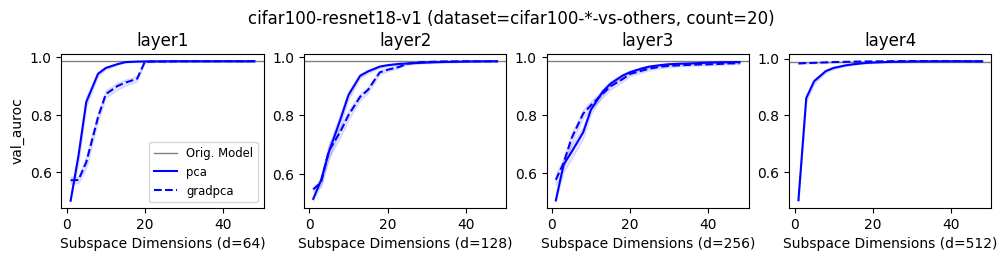

In [5]:
def alias(name):
    return {
        "prca-ablation-a-c": "prcaposdefv2",
    }.get(name, name)
    
def viz(
    dataset_name="cifar100-people-vs-others",
    model_name="cifar100-resnet18-v1",
    arr_layers=["layer1", "layer2", "layer3", "layer4"], 
    arr_basis_names=[
        "pca",
        "gradpca",
        "prcaposdef",
        "prca-ablation-a-c",
        # "prcasortabs",
        # "prca",
    ],
    stat_col="val_auroc",
    ref_col="ref_auroc",
    dict_color_ls={
        "pca":        ("blue", "-"),
        "gradpca":    ("blue", "--"),
        "prcaposdef": ("red",  "-"),
        "prca-ablation-a-c": ("red",  "--"),
    }
):
    ncols = len(arr_layers)
    plt.figure(figsize=(3*ncols, 2))
    
    
   
    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)
        for bix, basis_name in enumerate(arr_basis_names):
            df = load_data(
                model=model_name,
                layer=layer,
                # todo: we should aggregate this over several datasets
                dataset_name=dataset_name,
                basis_name=basis_name,
                ref_col=ref_col,
                stat_col=stat_col
            )
            if bix == 0:
                plt.axhline(df[ref_col]["mean"].values[-1], ls="-", color="gray", lw=1, label="Orig. Model")
                count = df[ref_col]["count"].values[-1]
                
            d = int(df.d["mean"].values[-1])
            div = 4
            max_k = 48
            selected = df.k <= max_k
            color, ls = dict_color_ls.get(basis_name, (None, None))

            arr_k = df["k"][selected]
            mean = df[stat_col]["mean"][selected]
            sem = df[stat_col]["sem"][selected]
            plt.plot(
                arr_k,
                mean,
                label=alias(basis_name),
                color=color,
                ls=ls,
                # marker=".",
            )
            plt.fill_between(
                arr_k,
                mean - sem,
                mean + sem,
                alpha=0.1,
                color=color
            )
            
        if lix == 0:
            plt.ylabel(stat_col)
            plt.legend(fontsize="small")
        
        plt.xlabel(f"Subspace Dimensions (d={d})")
    plt.suptitle(f"{model_name} (dataset={dataset_name}, count={count})", y=1.1)

viz(dataset_name="cifar100-*-vs-others", arr_basis_names=["pca", "gradpca"])

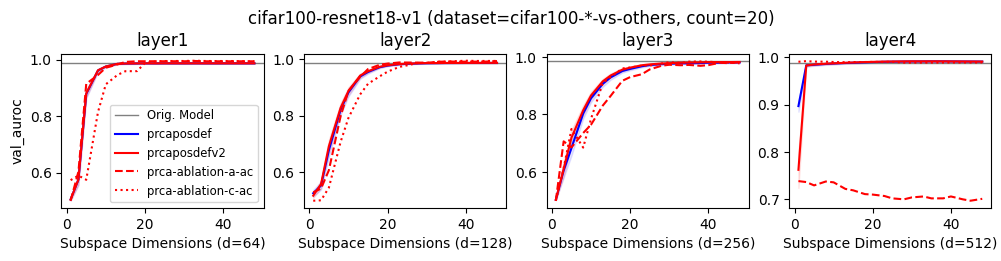

In [6]:
viz(
    dataset_name="cifar100-*-vs-others", 
    arr_basis_names=[
        "prcaposdef",
        "prca-ablation-a-c",
        "prca-ablation-a-ac",
        "prca-ablation-c-ac",
    ],
    dict_color_ls={
        "prcaposdef":        ("blue",  "-"),
        "prca-ablation-a-c": ("red",   "-"),
        "prca-ablation-a-ac":("red",   "--"),
        "prca-ablation-c-ac":("red",   ":"),
    },
    # arr_layers=["layer1"]
)

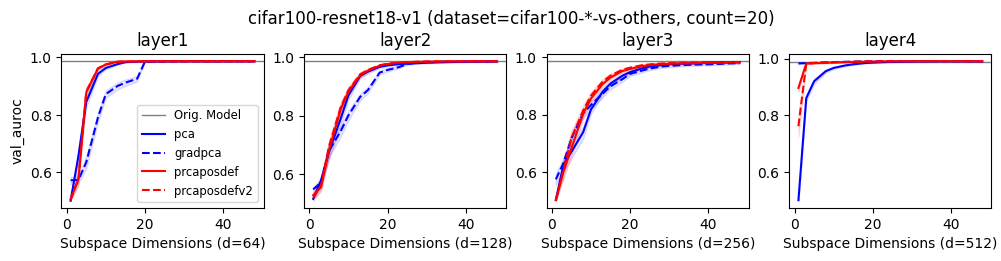

In [7]:
viz(dataset_name="cifar100-*-vs-others")

## ImageNet

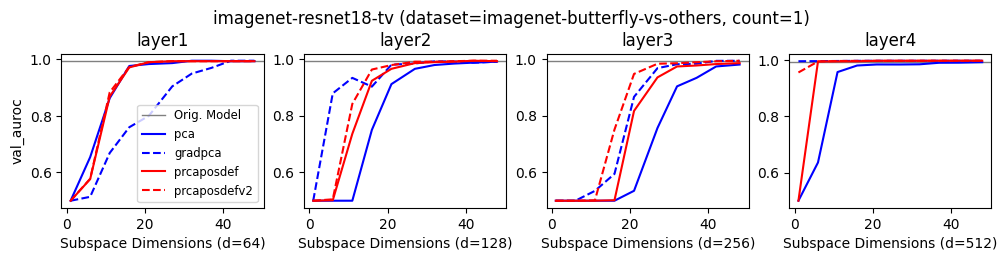

In [8]:
viz(
    model_name="imagenet-resnet18-tv", 
    dataset_name="imagenet-butterfly-vs-others", 
)

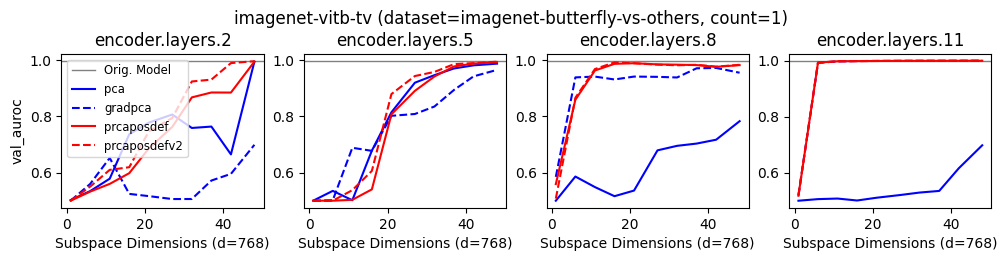

In [9]:
viz(
    model_name="imagenet-vitb-tv", 
    dataset_name="imagenet-butterfly-vs-others", 
    arr_layers=[
        "encoder.layers.2",
        "encoder.layers.5",
        "encoder.layers.8",
        "encoder.layers.11",
    ]
)

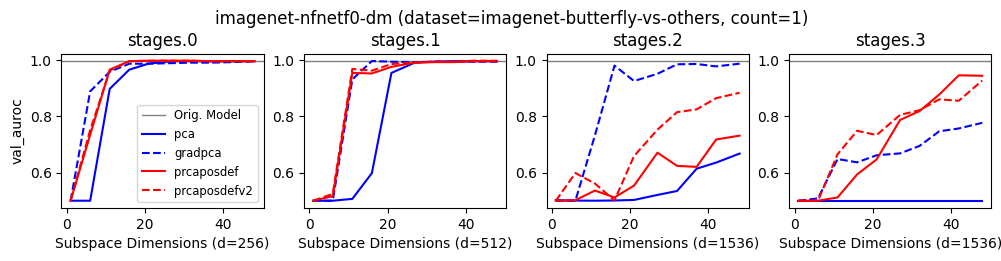

In [10]:
viz(
    model_name="imagenet-nfnetf0-dm", 
    dataset_name="imagenet-butterfly-vs-others", 
    arr_layers=[
        "stages.0",
        "stages.1", 
        "stages.2",
        "stages.3", 

    ],
)

# Subclass
## CIFAR-*

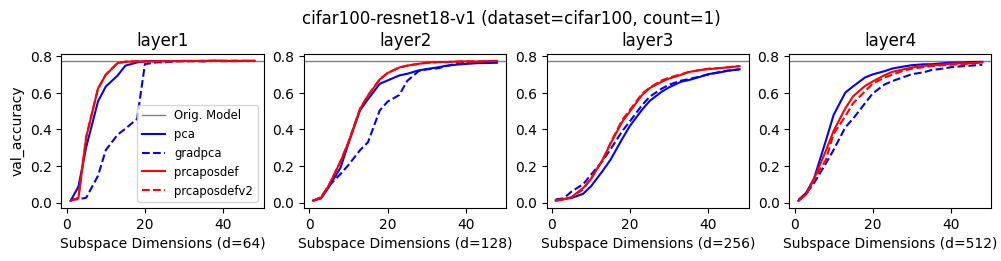

In [11]:
viz(
    model_name="cifar100-resnet18-v1", 
    dataset_name="cifar100", 
    stat_col="val_accuracy",
    ref_col="ref_accuracy",
)

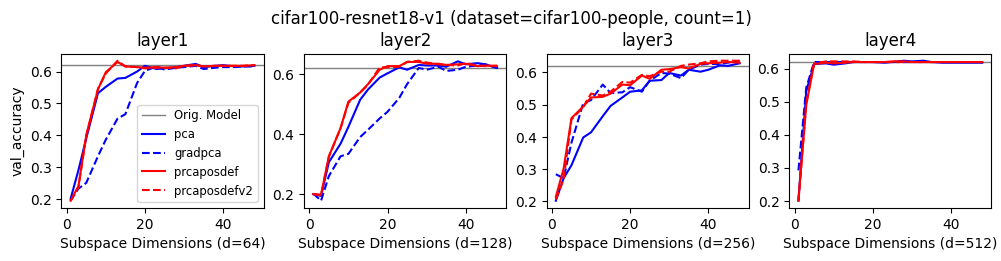

In [12]:
viz(
    model_name="cifar100-resnet18-v1", 
    dataset_name="cifar100-people", 
    stat_col="val_accuracy",
    ref_col="ref_accuracy"
)

## Imagenet-*

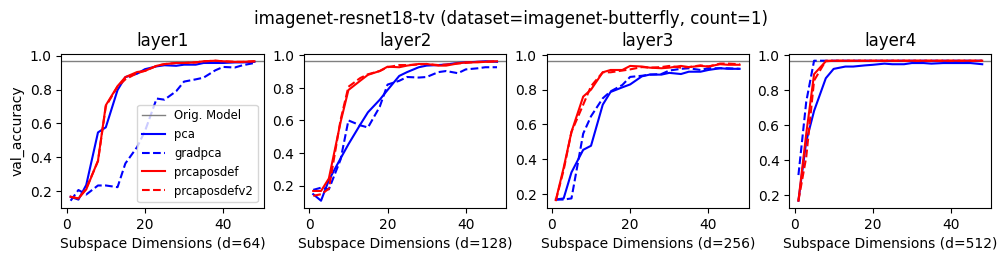

In [13]:
viz(
    model_name="imagenet-resnet18-tv", 
    dataset_name="imagenet-butterfly", 
    stat_col="val_accuracy",
    ref_col="ref_accuracy"
)

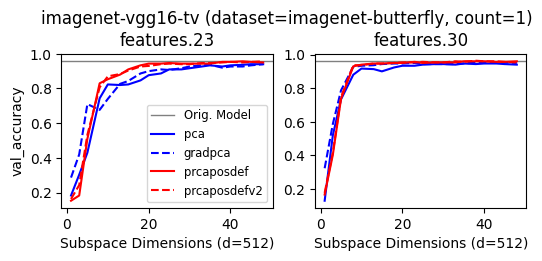

In [14]:
viz(
    model_name="imagenet-vgg16-tv", 
    dataset_name="imagenet-butterfly", 
    arr_layers=["features.23", "features.30"], # also do {9, 16}
    stat_col="val_accuracy",
    ref_col="ref_accuracy"
)

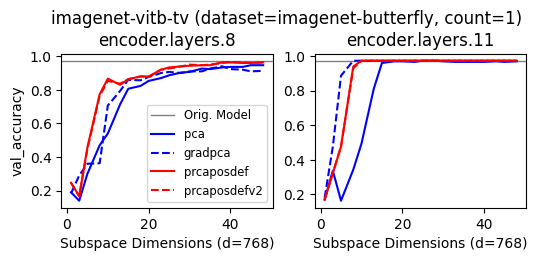

In [15]:
viz(
    model_name="imagenet-vitb-tv", 
    dataset_name="imagenet-butterfly", 
    arr_layers=["encoder.layers.8", "encoder.layers.11"], 
    stat_col="val_accuracy",
    ref_col="ref_accuracy"
)

# All Classes

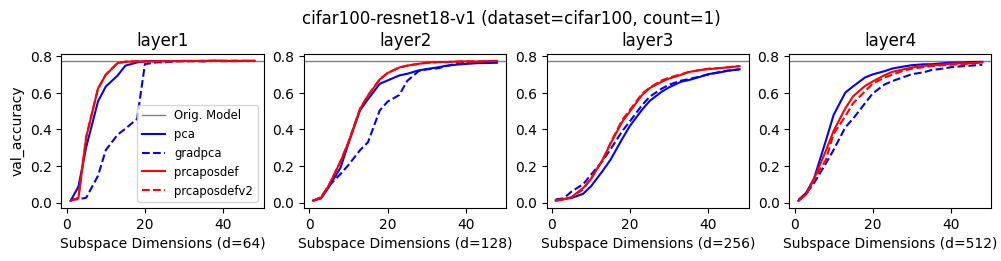

In [19]:
 viz(
    model_name="cifar100-resnet18-v1",
    dataset_name="cifar100", 
    stat_col="val_accuracy",
    ref_col="ref_accuracy"
)

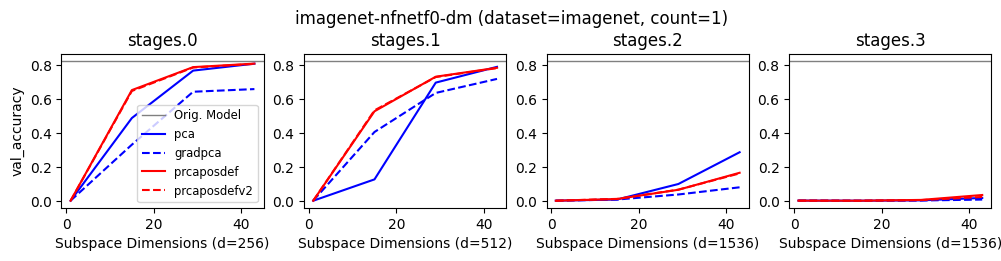

In [26]:
def ano():
        
    for model_name, arr_layers in [
        # ("imagenet-resnet18-tv", ["layer1", "layer2", "layer3", "layer4"]),
        # ("imagenet-resnet50-tv", ["layer1", "layer2", "layer3", "layer4"]),
        # ("imagenet-vitb-tv", ["encoder.layers.2", "encoder.layers.5", "encoder.layers.8", "encoder.layers.11",]),
        ("imagenet-nfnetf0-dm", [
            "stages.0",
            "stages.1",
            "stages.2",
            "stages.3",
        ]),
    ]:
        viz(
            model_name=model_name,
            dataset_name="imagenet", 
            arr_layers=arr_layers, 
            stat_col="val_accuracy",
            ref_col="ref_accuracy"
        )

        plt.show()
ano()

# End and Dev Note

In [17]:
# viz(dataset_name="cifar100-aquatic_mammals-vs-others")
# cifar100-aquatic_mammals-vs-others

In [18]:
for sc in constants.CIFAR100_SUPER_CLASSES:
    print(f"cifar100-{sc}-vs-others")

cifar100-aquatic_mammals-vs-others
cifar100-food_containers-vs-others
cifar100-small_mammals-vs-others
cifar100-large_natural_outdoor_scenes-vs-others
cifar100-large_carnivores-vs-others
cifar100-vehicles_1-vs-others
cifar100-people-vs-others
cifar100-flowers-vs-others
cifar100-medium_mammals-vs-others
cifar100-reptiles-vs-others
cifar100-large_omnivores_and_herbivores-vs-others
cifar100-fruit_and_vegetables-vs-others
cifar100-trees-vs-others
cifar100-household_furniture-vs-others
cifar100-vehicles_2-vs-others
cifar100-fish-vs-others
cifar100-household_electrical_devices-vs-others
cifar100-large_man_made_outdoor_things-vs-others
cifar100-insects-vs-others
cifar100-non_insect_invertebrates-vs-others
